In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import os
import itertools
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from PIL import Image
from tqdm.auto import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using Device: {device} | GPU Count: {torch.cuda.device_count()}")

Using Device: cuda | GPU Count: 2


In [2]:
BATCH_SIZE = 8          # Speed ke liye badha diya
IMG_SIZE = 128          # Speed ke liye half kar diya (128x128)
EPOCHS = 10             
LR = 0.0002
BETA1 = 0.5
BETA2 = 0.999
LAMBDA_CYCLE = 10.0
LAMBDA_ID = 5.0
MAX_CLASSES = 2         # Sirf 2 classes taake data jaldi load ho

# Paths
PHOTO_PATH = "/kaggle/input/datasets/ankitsheoran23/sketch-to-image/256x256/photo"
SKETCH_PATH = "/kaggle/input/datasets/ankitsheoran23/sketch-to-image/256x256/sketch"

In [3]:
class ResidualBlock(nn.Module):
    def __init__(self, in_features):
        super(ResidualBlock, self).__init__()
        self.block = nn.Sequential(
            nn.ReflectionPad2d(1),
            nn.Conv2d(in_features, in_features, 3),
            nn.InstanceNorm2d(in_features),
            nn.ReLU(inplace=True),
            nn.ReflectionPad2d(1),
            nn.Conv2d(in_features, in_features, 3),
            nn.InstanceNorm2d(in_features)
        )
    def forward(self, x): return x + self.block(x)

class Generator(nn.Module):
    def __init__(self, num_residual_blocks=6):
        super(Generator, self).__init__()
        model = [nn.ReflectionPad2d(3), nn.Conv2d(3, 64, 7), nn.InstanceNorm2d(64), nn.ReLU(inplace=True)]
        in_features = 64
        out_features = in_features * 2
        for _ in range(2):
            model += [nn.Conv2d(in_features, out_features, 3, stride=2, padding=1), nn.InstanceNorm2d(out_features), nn.ReLU(inplace=True)]
            in_features = out_features
            out_features = in_features * 2
        for _ in range(num_residual_blocks):
            model += [ResidualBlock(in_features)]
        out_features = in_features // 2
        for _ in range(2):
            model += [nn.ConvTranspose2d(in_features, out_features, 3, stride=2, padding=1, output_padding=1), nn.InstanceNorm2d(out_features), nn.ReLU(inplace=True)]
            in_features = out_features
            out_features = in_features // 2
        model += [nn.ReflectionPad2d(3), nn.Conv2d(64, 3, 7), nn.Tanh()]
        self.model = nn.Sequential(*model)
    def forward(self, x): return self.model(x)

class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Conv2d(3, 64, 4, stride=2, padding=1), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, 4, stride=2, padding=1), nn.InstanceNorm2d(128), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 256, 4, stride=2, padding=1), nn.InstanceNorm2d(256), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(256, 512, 4, padding=1), nn.InstanceNorm2d(512), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(512, 1, 4, padding=1)
        )
    def forward(self, x): return self.model(x)

In [4]:
class NestedCycleGANDataset(Dataset):
    def __init__(self, p_root, s_root, max_classes=2):
        self.transform = transforms.Compose([
            transforms.Resize((IMG_SIZE, IMG_SIZE)),
            transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
        ])
        
        all_classes = set()
        for tx in os.listdir(p_root):
            tx_path = os.path.join(p_root, tx)
            if os.path.isdir(tx_path):
                for cls in os.listdir(tx_path):
                    if os.path.isdir(os.path.join(tx_path, cls)): all_classes.add(cls)
        
        self.selected_classes = sorted(list(all_classes))[:max_classes]

        def collect_files(root_dir):
            paths = []
            for tx in os.listdir(root_dir):
                tx_path = os.path.join(root_dir, tx)
                if not os.path.isdir(tx_path): continue
                for cls in self.selected_classes:
                    cls_path = os.path.join(tx_path, cls)
                    if os.path.exists(cls_path):
                        for f in os.listdir(cls_path):
                            if f.lower().endswith(('.png', '.jpg', '.jpeg')):
                                paths.append(os.path.join(cls_path, f))
            return paths

        self.photo_files = collect_files(p_root)
        self.sketch_files = collect_files(s_root)
        self.length = max(len(self.photo_files), len(self.sketch_files))

    def __len__(self): return self.length
    def __getitem__(self, idx):
        p_img = Image.open(self.photo_files[idx % len(self.photo_files)]).convert("RGB")
        s_img = Image.open(self.sketch_files[idx % len(self.sketch_files)]).convert("RGB")
        return self.transform(s_img), self.transform(p_img)

dataset = NestedCycleGANDataset(PHOTO_PATH, SKETCH_PATH, max_classes=MAX_CLASSES)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
print(f"Ready! Classes: {dataset.selected_classes} | Photos: {len(dataset.photo_files)} | Sketches: {len(dataset.sketch_files)}")

Ready! Classes: ['airplane', 'alarm_clock'] | Photos: 400 | Sketches: 7680


In [5]:
G_AB = Generator().to(device); G_BA = Generator().to(device)
D_A = Discriminator().to(device); D_B = Discriminator().to(device)

if torch.cuda.device_count() > 1:
    G_AB = nn.DataParallel(G_AB); G_BA = nn.DataParallel(G_BA)
    D_A = nn.DataParallel(D_A); D_B = nn.DataParallel(D_B)

criterion_GAN = nn.MSELoss()
criterion_cycle = nn.L1Loss()
criterion_identity = nn.L1Loss()

optimizer_G = torch.optim.Adam(itertools.chain(G_AB.parameters(), G_BA.parameters()), lr=LR, betas=(BETA1, BETA2))
optimizer_D_A = torch.optim.Adam(D_A.parameters(), lr=LR, betas=(BETA1, BETA2))
optimizer_D_B = torch.optim.Adam(D_B.parameters(), lr=LR, betas=(BETA1, BETA2))

In [6]:
print("Starting Fast Training...")

for epoch in range(EPOCHS):
    progress_bar = tqdm(loader, desc=f"Epoch {epoch+1}/{EPOCHS}")
    for i, (real_A, real_B) in enumerate(progress_bar):
        if i >= 400: break # Har epoch ko 400 steps par limit kar diya fast training ke liye
            
        real_A, real_B = real_A.to(device), real_B.to(device)
        
        # Dynamic label matching
        out_shape = D_A(real_A).shape[2:] 
        valid = torch.ones((real_A.size(0), 1, *out_shape), device=device, requires_grad=False)
        fake = torch.zeros((real_A.size(0), 1, *out_shape), device=device, requires_grad=False)

        # Train G
        optimizer_G.zero_grad()
        loss_id = (criterion_identity(G_BA(real_A), real_A) + criterion_identity(G_AB(real_B), real_B)) / 2
        fake_B = G_AB(real_A); loss_GAN_AB = criterion_GAN(D_B(fake_B), valid)
        fake_A = G_BA(real_B); loss_GAN_BA = criterion_GAN(D_A(fake_A), valid)
        loss_GAN = (loss_GAN_AB + loss_GAN_BA) / 2
        loss_cycle = (criterion_cycle(G_BA(fake_B), real_A) + criterion_cycle(G_AB(fake_A), real_B)) / 2
        loss_G = loss_GAN + LAMBDA_CYCLE * loss_cycle + LAMBDA_ID * loss_id
        loss_G.backward(); optimizer_G.step()

        # Train D
        optimizer_D_A.zero_grad()
        loss_D_A = (criterion_GAN(D_A(real_A), valid) + criterion_GAN(D_A(fake_A.detach()), fake)) / 2
        loss_D_A.backward(); optimizer_D_A.step()

        optimizer_D_B.zero_grad()
        loss_D_B = (criterion_GAN(D_B(real_B), valid) + criterion_GAN(D_B(fake_B.detach()), fake)) / 2
        loss_D_B.backward(); optimizer_D_B.step()

        progress_bar.set_postfix(G_loss=f"{loss_G.item():.4f}", D_loss=f"{(loss_D_A.item()+loss_D_B.item())/2:.4f}")

print("Training finished!")

Starting Fast Training...


Epoch 1/10:   0%|          | 0/960 [00:00<?, ?it/s]

Epoch 2/10:   0%|          | 0/960 [00:00<?, ?it/s]

Epoch 3/10:   0%|          | 0/960 [00:00<?, ?it/s]

Epoch 4/10:   0%|          | 0/960 [00:00<?, ?it/s]

...

Epoch 7/10:   0%|          | 0/960 [00:00<?, ?it/s]

Epoch 8/10:   0%|          | 0/960 [00:00<?, ?it/s]

Epoch 9/10:   0%|          | 0/960 [00:00<?, ?it/s]

Epoch 10/10:   0%|          | 0/960 [00:00<?, ?it/s]

Training finished!


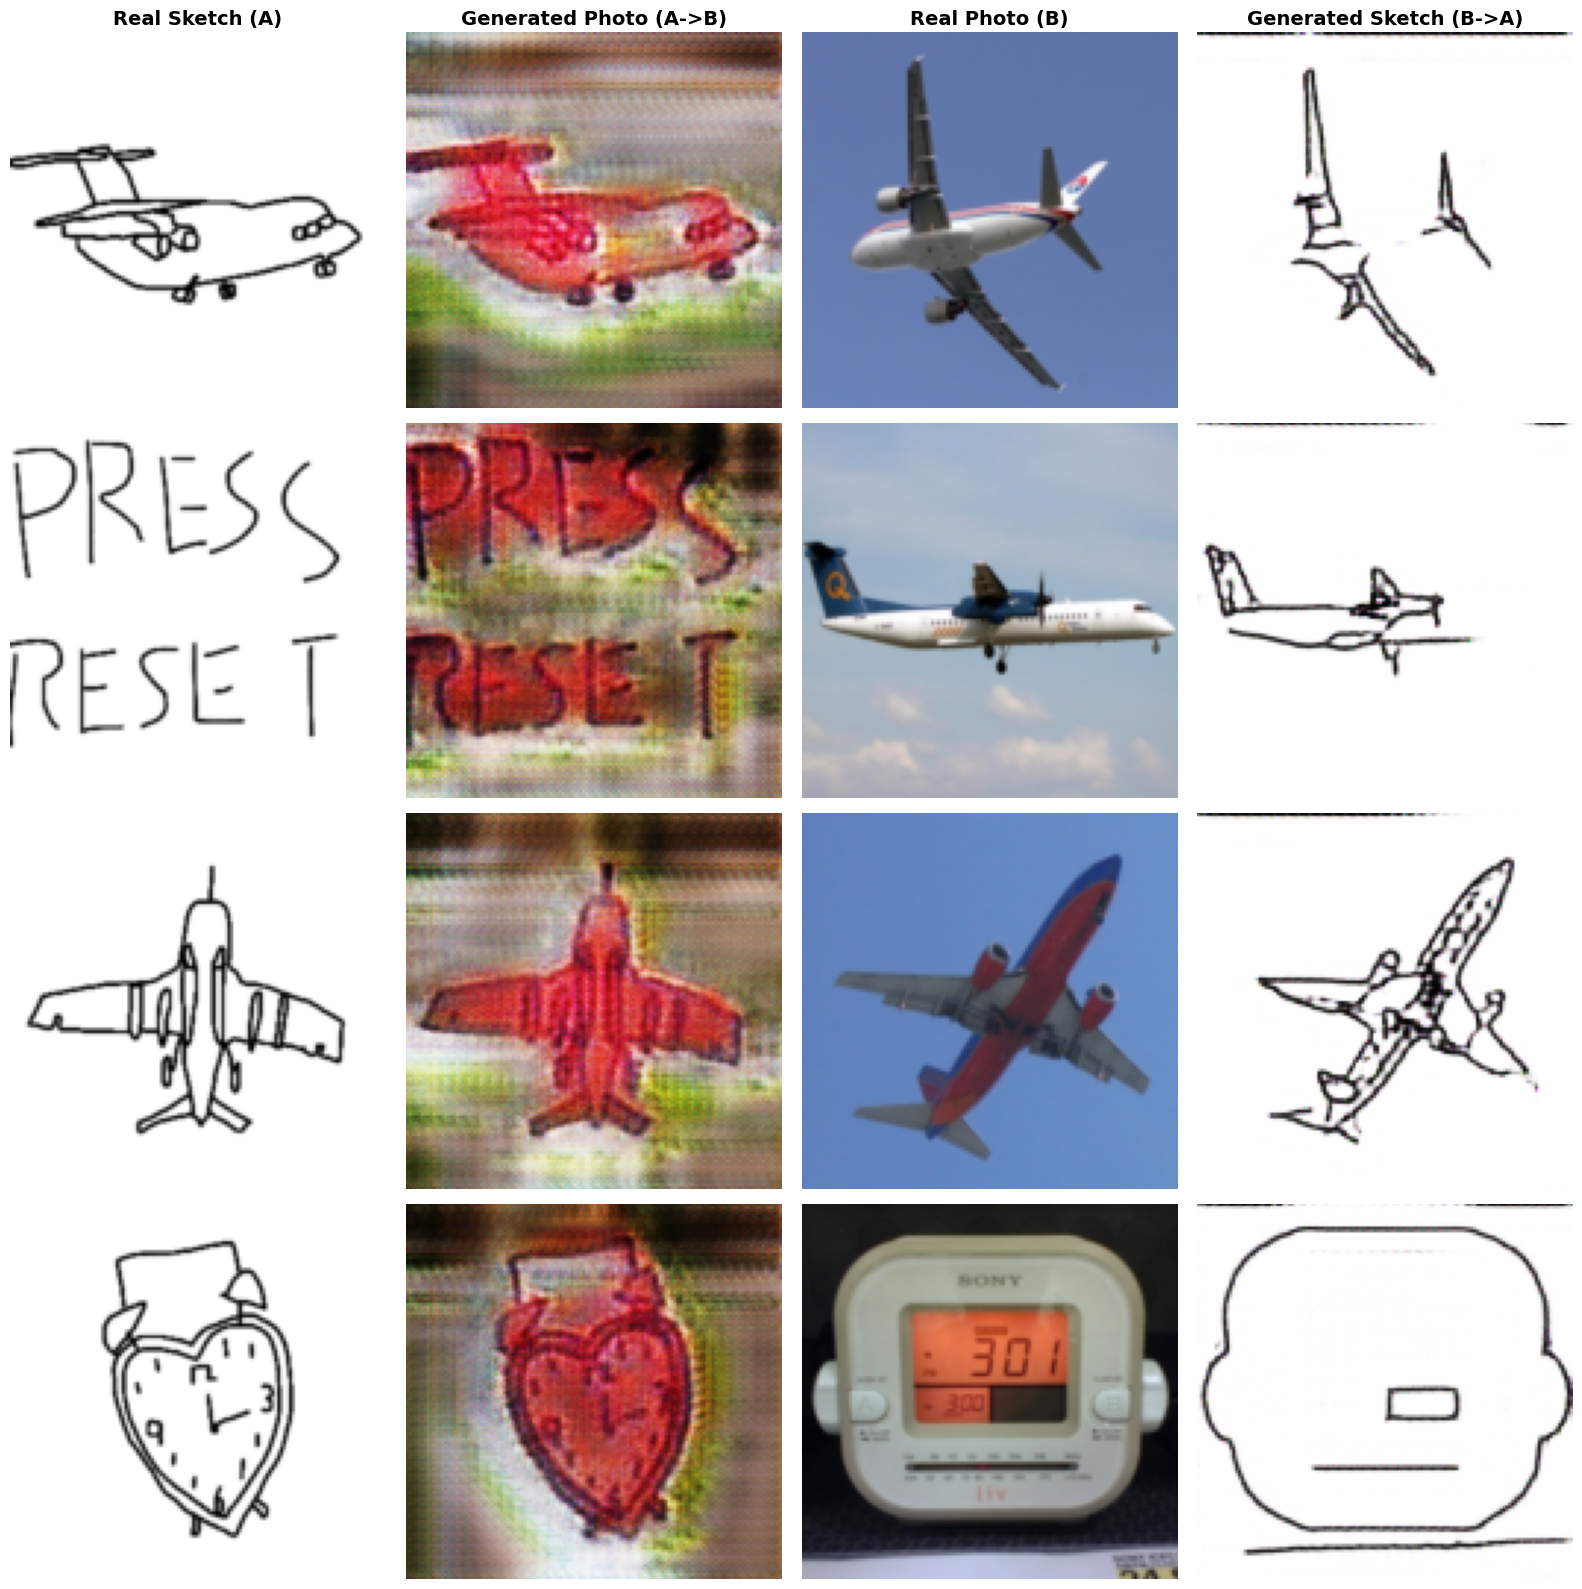

In [8]:
import matplotlib.pyplot as plt
import numpy as np

def show_generated_results(num_samples=4):
    # Models ko evaluation mode mein daalein (taake Dropout/BatchNorm test mode mein kaam karein)
    G_AB.eval()
    G_BA.eval()
    
    # Dataloader se ek random batch lein
    real_A, real_B = next(iter(loader))
    real_A = real_A.to(device)
    real_B = real_B.to(device)
    
    # Gradients calculate kiye bina images generate karein (Memory bachane ke liye)
    with torch.no_grad():
        fake_B = G_AB(real_A)  # Sketch ko Photo banaya
        fake_A = G_BA(real_B)  # Photo ko Sketch banaya
        
    # Tensor ko image mein convert karne aur denormalize (-1, 1 se 0, 1) karne ka function
    def to_img(tensor):
        img = tensor.cpu().detach()
        img = img * 0.5 + 0.5  # Denormalize
        img = torch.clamp(img, 0, 1) # Values ko 0-1 ke beech fix rakhein
        return img.permute(1, 2, 0).numpy() # (Channels, Height, Width) -> (Height, Width, Channels)

    # Plotting ka setup
    fig, axes = plt.subplots(num_samples, 4, figsize=(16, 4 * num_samples))
    titles = ['Real Sketch (A)', 'Generated Photo (A->B)', 'Real Photo (B)', 'Generated Sketch (B->A)']
    
    for i in range(num_samples):
        # 1. Real Sketch
        ax = axes[i, 0] if num_samples > 1 else axes[0]
        ax.imshow(to_img(real_A[i]))
        if i == 0: ax.set_title(titles[0], fontsize=14, fontweight='bold')
        ax.axis('off')
        
        # 2. Generated Photo
        ax = axes[i, 1] if num_samples > 1 else axes[1]
        ax.imshow(to_img(fake_B[i]))
        if i == 0: ax.set_title(titles[1], fontsize=14, fontweight='bold')
        ax.axis('off')
        
        # 3. Real Photo
        ax = axes[i, 2] if num_samples > 1 else axes[2]
        ax.imshow(to_img(real_B[i]))
        if i == 0: ax.set_title(titles[2], fontsize=14, fontweight='bold')
        ax.axis('off')
        
        # 4. Generated Sketch
        ax = axes[i, 3] if num_samples > 1 else axes[3]
        ax.imshow(to_img(fake_A[i]))
        if i == 0: ax.set_title(titles[3], fontsize=14, fontweight='bold')
        ax.axis('off')
        
    plt.tight_layout()
    plt.show()
    
    # Models ko wapas train mode mein daal dein (agar mazeed training karni ho)
    G_AB.train()
    G_BA.train()

# 4 images ka result show karein (agar batch size chota hai toh is number ko adjust kar lein)
show_generated_results(num_samples=4)

In [ ]:
import os

print("Starting Full Training Loop (No Limits)...")

# Models save karne ke liye ek folder bana lete hain
os.makedirs("saved_models", exist_ok=True)

for epoch in range(EPOCHS):
    progress_bar = tqdm(loader, desc=f"Epoch {epoch+1}/{EPOCHS}")
    for i, (real_A, real_B) in enumerate(progress_bar):
        
        # Yahan se limit hata di gayi hai taake poora data train ho
            
        real_A, real_B = real_A.to(device), real_B.to(device)
        
        # Dynamic label matching
        out_shape = D_A(real_A).shape[2:] 
        valid = torch.ones((real_A.size(0), 1, *out_shape), device=device, requires_grad=False)
        fake = torch.zeros((real_A.size(0), 1, *out_shape), device=device, requires_grad=False)

        # ------------------
        # Train Generators
        # ------------------
        optimizer_G.zero_grad()
        loss_id = (criterion_identity(G_BA(real_A), real_A) + criterion_identity(G_AB(real_B), real_B)) / 2
        fake_B = G_AB(real_A); loss_GAN_AB = criterion_GAN(D_B(fake_B), valid)
        fake_A = G_BA(real_B); loss_GAN_BA = criterion_GAN(D_A(fake_A), valid)
        loss_GAN = (loss_GAN_AB + loss_GAN_BA) / 2
        loss_cycle = (criterion_cycle(G_BA(fake_B), real_A) + criterion_cycle(G_AB(fake_A), real_B)) / 2
        loss_G = loss_GAN + LAMBDA_CYCLE * loss_cycle + LAMBDA_ID * loss_id
        loss_G.backward(); optimizer_G.step()

        # ------------------
        # Train Discriminators
        # ------------------
        optimizer_D_A.zero_grad()
        loss_D_A = (criterion_GAN(D_A(real_A), valid) + criterion_GAN(D_A(fake_A.detach()), fake)) / 2
        loss_D_A.backward(); optimizer_D_A.step()

        optimizer_D_B.zero_grad()
        loss_D_B = (criterion_GAN(D_B(real_B), valid) + criterion_GAN(D_B(fake_B.detach()), fake)) / 2
        loss_D_B.backward(); optimizer_D_B.step()

        progress_bar.set_postfix(G_loss=f"{loss_G.item():.4f}", D_loss=f"{(loss_D_A.item()+loss_D_B.item())/2:.4f}")

    # --- MODEL SAVING ---
    # Har epoch ke khatam hone par models save honge
    torch.save(G_AB.state_dict(), f"saved_models/G_AB_epoch_{epoch+1}.pth")
    torch.save(G_BA.state_dict(), f"saved_models/G_BA_epoch_{epoch+1}.pth")
    # Agar Discriminators bhi save karne hain (optional):
    torch.save(D_A.state_dict(), f"saved_models/D_A_epoch_{epoch+1}.pth")
    torch.save(D_B.state_dict(), f"saved_models/D_B_epoch_{epoch+1}.pth")
    
    print(f"\nModels successfully saved for Epoch {epoch+1} in 'saved_models' folder.")

print("Full Training finished!")